<b>This notebook provides a small example of how to generate the periodic table used in the article, colored according to property values. All values shown here are purely demonstrative.

In [1]:
import pandas as pd

# Dist Ele
element_values  = {
    'Li': 1.26503, 'Na': 1.11868, 'K': 0.9257, 'Mg': 1.14672, 'Ca': 1.21557, 'Al': 0.72319, 'Ga':1.51992 , 'Ge':1.47438 , 'Cu':1.22176 , 'Zn':1.26863 ,
    'Sc': 1.10038, 'Ti': 0.65271, 'V':1.04592 , 'Cr': 0.98192, 'Mn': 0.89719, 'Fe':0.94858, 'Co':1.21557 , 'Ni':0.52821}


In [2]:
elements = [
    # Period 1
    (1, 1, 'H'), (18, 1, 'He'),
    # Period 2
    (1, 2, 'Li'), (2, 2, 'Be'), (13, 2, 'B'), (14, 2, 'C'), (15, 2, 'N'),
    (16, 2, 'O'), (17, 2, 'F'), (18, 2, 'Ne'),
    # Period 3
    (1, 3, 'Na'), (2, 3, 'Mg'), (13, 3, 'Al'), (14, 3, 'Si'), (15, 3, 'P'),
    (16, 3, 'S'), (17, 3, 'Cl'), (18, 3, 'Ar'),
    # Period 4
    (1, 4, 'K'), (2, 4, 'Ca'), (3, 4, 'Sc'), (4, 4, 'Ti'), (5, 4, 'V'),
    (6, 4, 'Cr'), (7, 4, 'Mn'), (8, 4, 'Fe'), (9, 4, 'Co'), (10, 4, 'Ni'),
    (11, 4, 'Cu'), (12, 4, 'Zn'), (13, 4, 'Ga'), (14, 4, 'Ge'),
    (15, 4, 'As'), (16, 4, 'Se'), (17, 4, 'Br'), (18, 4, 'Kr'),
    # Period 5
    (1, 5, 'Rb'), (2, 5, 'Sr'), (3, 5, 'Y'), (4, 5, 'Zr'), (5, 5, 'Nb'),
    (6, 5, 'Mo'), (7, 5, 'Tc'), (8, 5, 'Ru'), (9, 5, 'Rh'), (10, 5, 'Pd'),
    (11, 5, 'Ag'), (12, 5, 'Cd'), (13, 5, 'In'), (14, 5, 'Sn'),
    (15, 5, 'Sb'), (16, 5, 'Te'), (17, 5, 'I'), (18, 5, 'Xe')
]

# Create the DataFrame
df = pd.DataFrame(elements, columns=["group", "period", "symbol"])
df["value"] = df["symbol"].map(element_values)

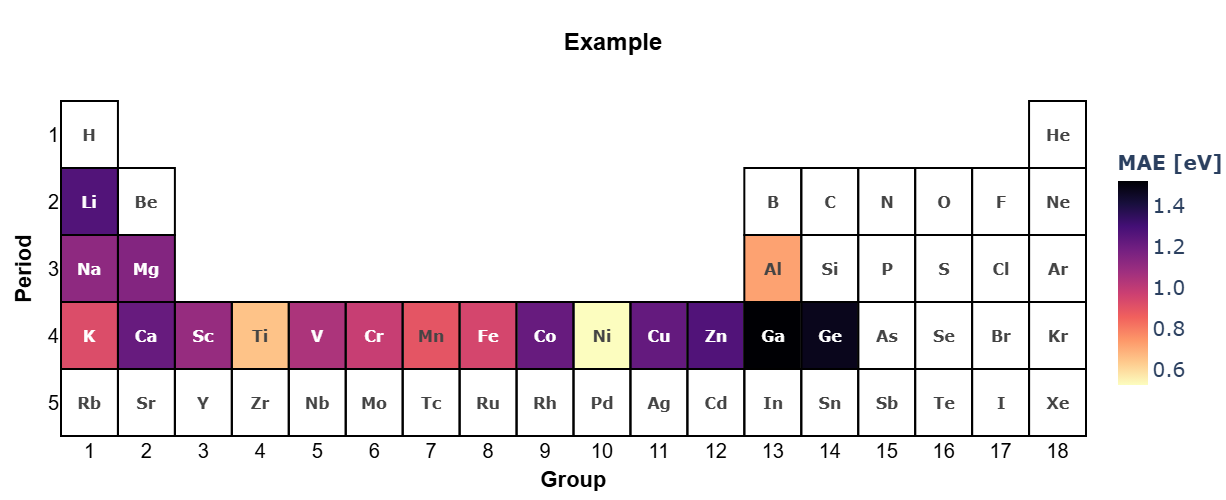

In [3]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# df is your DataFrame with columns: "period" (int), "group" (int), "symbol" (str), "value" (int/float)

rows, cols = 5, 18
z = np.full((rows, cols), np.nan)
labels = np.full((rows, cols), '', dtype=object)

# Fill z and labels
for _, row in df.iterrows():
    r = row["period"] - 1
    c = row["group"] - 1
    labels[r, c] = row["symbol"]
    z[r, c] = row["value"] if pd.notnull(row["value"]) else -1 

# Mask -1 values (used for missing data)
z_masked = np.where(z == -1, np.nan, z)

# Create heatmap
fig = go.Figure(data=go.Heatmap(
    z=z_masked,
    text=labels,
    texttemplate="<b>%{text}</b>",
    textfont={"size": 16},
    hoverinfo="text+z",
    colorscale="magma_r",  # reversed colormap
    colorbar=dict(
    title=dict(
        text="<b>MAE [eV]</b>",
        side="top",
        font=dict(size=20)
    ),
    orientation="v",
    x=1.02,
    xanchor="left",
    tickfont=dict(size=20),
    thickness=30,
    len=0.75,
    tickformat=".1f" 
),

    zmin=np.nanmin(z_masked),
    zmax=np.nanmax(z_masked),
    xgap=2,
    ygap=2
))

for r in range(rows):
    for c in range(cols):
        if labels[r, c] != '' and np.isnan(z[r, c]):
            fig.add_shape(
                type="rect",
                x0=c - 0.5, x1=c + 0.5,
                y0=r - 0.5, y1=r + 0.5,
                line=dict(color="black", width=1.5),
                fillcolor="lightgray",
                layer="below"
            )
            fig.add_annotation(
                x=c, y=r,
                text=f"<b>{labels[r, c]}</b>",
                showarrow=False,
                font=dict(size=20, color="black")
            )

# Borders for all defined elements
for _, row in df.iterrows():
    r = row["period"] - 1
    c = row["group"] - 1
    fig.add_shape(
        type="rect",
        x0=c - 0.5, x1=c + 0.5,
        y0=r - 0.5, y1=r + 0.5,
        line=dict(color="black", width=2),
        layer="above"
    )

# Layout with title and axis labels
fig.update_layout(
    title=dict(
        text="<b>Example</b>",
        x=0.5,
        xanchor="center",
        font=dict(size=24, family="Arial", color="black")
    ),
    xaxis=dict(
        tickmode="array",
        tickvals=list(range(18)),
        ticktext=[str(i+1) for i in range(18)],
        showgrid=False,
        zeroline=False,
        tickfont=dict(size=20, family="Arial", color="black"),
        title=dict(
            text="<b>Group</b>",
            font=dict(size=22, family="Arial", color="black"),
            standoff=10
        )
    ),
    yaxis=dict(
        tickmode="array",
        tickvals=list(range(rows)),
        ticktext=[1, 2, 3, 4, 5],
        autorange="reversed",
        showgrid=False,
        zeroline=False,
        tickfont=dict(size=20, family="Arial", color="black"),
        title=dict(
            text="<b>Period</b>",
            font=dict(size=22, family="Arial", color="black"),
            standoff=10
        )
    ),
    plot_bgcolor="white",
    margin=dict(l=60, r=100, t=100, b=60),
    height=500
)

# Show figure
fig.show()
